# oracle regret report

This compares three ways a real Grand Prix could have gone, all priced with the same tyre-degradation-and-pit-loss cost model: what the driver actually did, what this project's stochastic optimizer would have called from the same pre-race information, and what a perfect-foresight oracle would have called knowing exactly when the safety cars were going to come out. All three are scored against the same real race, so the safety car pattern is held fixed and only the strategy varies.

The comparison only covers driver-races where the real strategy exactly matches one of the optimizer's five candidate compound sequences, covers the full race distance, and never runs a stint shorter than the solver's own minimum stint length -- anything else can't be priced against the same cost model the solver searches over, so it gets dropped rather than approximated. The exact count and share of races that drops is computed live below, not guessed at here.

One more scope note: this is strictly a tyre-and-pit-stop time cost. The field-interaction model that estimates how safety cars and traffic move cars up and down the order has its own calibration error, and none of that is folded into these regret numbers -- a strategy that looks cheap in seconds here could still cost or gain positions in ways this notebook doesn't try to capture.

In [1]:
import sys

sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import pandas as pd

report = pd.read_csv("../data/processed/regret_report.csv")
report.shape

(652, 11)

In [2]:
from modeling.evaluation import position_gap

laps = pd.read_parquet("../data/processed/laps.parquet")
results = pd.read_parquet("../data/processed/results.parquet")

finished = results[results["Status"].eq("Finished") | results["Status"].str.contains("Lap", na=False)]
classified = finished[["Season", "Round", "Code"]].drop_duplicates()
excluded = len(classified) - len(report)

print(f"{len(report)} driver-races included out of {len(classified)} classified finishers")
print(
    f"{excluded} dropped ({excluded / len(classified):.1%}) for not matching a candidate compound "
    "sequence, not covering the full race distance, or running a stint shorter than the solver allows"
)

mean_actual_regret = report["actual_regret_seconds"].mean()
median_actual_regret = report["actual_regret_seconds"].median()
mean_policy_regret = report["policy_regret_seconds"].mean()
median_policy_regret = report["policy_regret_seconds"].median()
captured_fraction = 1 - (mean_policy_regret / mean_actual_regret) if mean_actual_regret > 0 else float("nan")

print(f"mean actual regret vs. oracle: {mean_actual_regret:.2f}s (median {median_actual_regret:.2f}s)")
print(f"mean policy regret vs. oracle: {mean_policy_regret:.2f}s (median {median_policy_regret:.2f}s)")
print(f"policy captured {captured_fraction:.1%} of the value perfect information was worth over what actually happened")

try:
    seconds_per_position = position_gap.estimate_seconds_per_position(laps, results)
    print(
        f"perfect information was worth {mean_actual_regret / seconds_per_position:.2f} positions per race "
        f"(at {seconds_per_position:.1f}s/position, from real finishing gaps)"
    )
except ValueError as exc:
    print(f"skipped position-equivalent conversion: {exc}")

652 driver-races included out of 3134 classified finishers
2482 dropped (79.2%) for not matching a candidate compound sequence, not covering the full race distance, or running a stint shorter than the solver allows
mean actual regret vs. oracle: 15.61s (median 13.01s)
mean policy regret vs. oracle: 6.61s (median 0.35s)
policy captured 57.6% of the value perfect information was worth over what actually happened
perfect information was worth 4.19 positions per race (at 3.7s/position, from real finishing gaps)


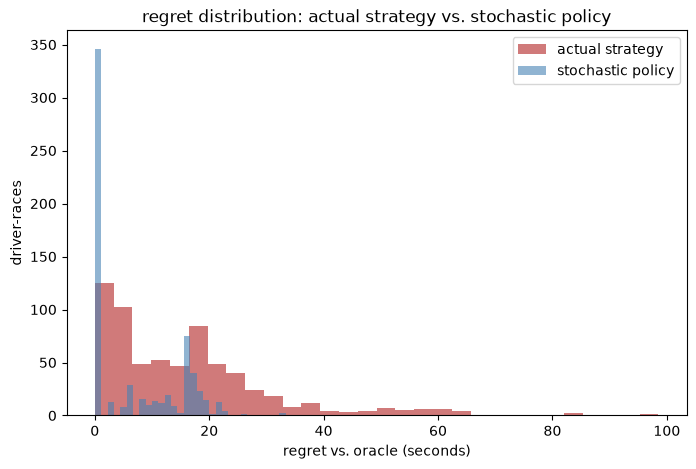

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
bins = 30
ax.hist(report["actual_regret_seconds"], bins=bins, alpha=0.6, label="actual strategy", color="firebrick")
ax.hist(report["policy_regret_seconds"], bins=bins, alpha=0.6, label="stochastic policy", color="steelblue")
ax.set_xlabel("regret vs. oracle (seconds)")
ax.set_ylabel("driver-races")
ax.set_title("regret distribution: actual strategy vs. stochastic policy")
ax.legend()
plt.show()

In [4]:
circuit_summary = (
    report.groupby("circuit_id")[["actual_regret_seconds", "policy_regret_seconds"]]
    .agg(["mean", "count"])
    .sort_values(("actual_regret_seconds", "mean"), ascending=False)
)
circuit_summary

actual_regret_seconds       policy_regret_seconds      
                               mean count                  mean count
circuit_id                                                           
nurburgring               63.141000     1              0.000000     1
zandvoort                 48.453637     8              2.655650     8
imola                     38.970886    14             10.963800    14
losail                    36.492364     7             19.809650     7
interlagos                33.738567     3              3.601900     3
marina_bay                29.901912    34             11.019147    34
monaco                    24.688867    15              2.121373    15
albert_park               23.048833    21              2.066167    21
sochi                     22.361875    12             10.640146    12
red_bull_ring             19.798343    29              0.538809    29
bahrain                   19.493661    18              5.753900    18
villeneuve                18.396833    15             11.478833    15
shanghai                  16.686469    26              8.511085    26
rodriguez                 16.596621    29              3.948276    29
miami                     14.596327    44              8.230491    44
vegas                     14.428227    15             15.184347    15
silverstone               13.440826    31             10.134903    31
ricard                    13.194968    25              8.980888    25
portimao                  12.095000     4              0.010000     4
suzuka                    11.863203    33              0.163030    33
spa                       11.721937    38              3.681705    38
hungaroring               11.311875    20              0.045000    20
monza                     11.004486    56              7.681221    56
baku                      10.808390    40              9.031010    40
americas                  10.594593    21              0.141869    21
catalunya                  7.165000     8              0.120000     8
jeddah                     6.793381    42             13.895190    42
yas_marina                 5.583802    43              3.013158    43